In [35]:
import pandas as pd
Sales = pd.read_csv('../LTV-Capstone-Project/Data/Online_Sales.csv')
Coupon = pd.read_csv('../LTV-Capstone-Project/Data/Discount_Coupon.csv')

In [36]:
ltv_final = pd.read_csv("Customer_LTV_Summary.csv")
ltv_final.head(2)

,customer_id,frequency,recency,T,monetary_value,predicted_purchases_6m,predicted_avg_value,predicted_ltv_6m,gender,location,tenure_months
0,12346,0.0,0.0,107.0,0.000,0.486163,1265.594052,615.284554,F,New York,31
1,12347,2.0,223.0,282.0,1163.375,0.867946,1240.987166,1077.109890,M,New York,20


In [39]:
print(Coupon.dtypes)
print(Coupon['month'].unique())

month               object
product_category    object
coupon_code         object
discount_pct         int64
dtype: object
['Jan' 'Feb' 'Mar' 'Apr' 'May' 'Jun' 'Jul' 'Aug' 'Sep' 'Oct' 'Nov' 'Dec']


In [41]:
# Cleaning date format - Map month abbreviations to month numbers
import calendar
month_map = {abbr: num for num, abbr in enumerate(calendar.month_abbr) if abbr}
Coupon['month_num'] = Coupon['month'].map(month_map)

In [42]:
# Create Month_Num in the Sales DataFrame
Sales['transaction_date'] = pd.to_datetime(Sales['transaction_date'], errors='coerce')
Sales['month_num'] = Sales['transaction_date'].dt.month

In [43]:
# Normalize Product_Category in both tables
Sales['product_category'] = Sales['product_category'].str.strip().str.upper()
Coupon['product_category'] = Coupon['product_category'].str.strip().str.upper()

In [44]:
Coupon.head()

,month,product_category,coupon_code,discount_pct,month_num
0,Jan,APPAREL,SALE10,10,1
1,Feb,APPAREL,SALE20,20,2
2,Mar,APPAREL,SALE30,30,3
3,Jan,NEST-USA,ELEC10,10,1
4,Feb,NEST-USA,ELEC20,20,2


In [45]:
# Cleaning date format to merge Sales and Coupon data
SalesCoupon = Sales.merge(
    Coupon[['month_num', 'product_category', 'coupon_code', 'discount_pct']],
    on=['month_num', 'product_category'],
    how='left',
    indicator=True
)

print(SalesCoupon['_merge'].value_counts())
print(SalesCoupon.loc[SalesCoupon['_merge']=='both',
                      ['month_num', 'product_category', 'coupon_code', 'discount_pct']].head())

_merge
both          52524
left_only       400
right_only        0
Name: count, dtype: int64
   month_num product_category coupon_code  discount_pct
0          1         NEST-USA      ELEC10          10.0
1          1         NEST-USA      ELEC10          10.0
2          1           OFFICE       OFF10          10.0
3          1          APPAREL      SALE10          10.0
4          1             BAGS       AIO10          10.0


In [46]:
#Calculate Marketing Spend
SalesCoupon['marketing_spend'] = (
    SalesCoupon['avg_price'] * SalesCoupon['quantity'] * SalesCoupon['discount_pct'] / 100
)
customer_metrics = SalesCoupon.groupby('customer_id').agg({
    'marketing_spend': 'sum'
}).reset_index()


In [47]:
#Aggregate Costs and Benefits Per Customer
customer_roi = ltv_final.merge(customer_metrics, on='customer_id', how='left')
customer_roi['marketing_spend'] = customer_roi['marketing_spend'].fillna(0)


In [48]:
#ROI calculation

def compute_roi(row):
    spend = row['marketing_spend']
    ltv = row['predicted_ltv_6m']
    return (ltv - spend) / spend * 100 if spend > 0 else None

customer_roi['roi_pct'] = customer_roi.apply(compute_roi, axis=1)
customer_roi['roi_ratio'] = customer_roi.apply(
    lambda r: r['predicted_ltv_6m'] / r['marketing_spend'] if r['marketing_spend'] > 0 else None,
    axis=1
)

In [49]:
#ROI calculation by location and gender
roi_by_location = customer_roi.groupby('location')['roi_ratio'].mean().reset_index()
roi_by_gender = customer_roi.groupby('gender')['roi_ratio'].mean().reset_index()

Interpretation & Benchmarks

ROI ratio > 1 means you earn more in LTV than spent on coupon costs.
ROI ratio = 2 means every $1 spent generates $2 in future value, or 100% ROI.
Industry benchmarks: 200–500% marketing ROI (2–5×) is considered good in e-commerce

| Metric                     | Formula                                    |
| -------------------------- | ------------------------------------------ |
| Marketing Spend (per cust) | `Avg_Price × Quantity × Discount_pct /100` |
| Predicted Return (LTV)     | `predicted_LTV_6m` from lifetimes model    |
| ROI (%)                    | `(LTV – Spend) / Spend × 100`              |
| ROI Ratio                  | `LTV / Spend`                              |


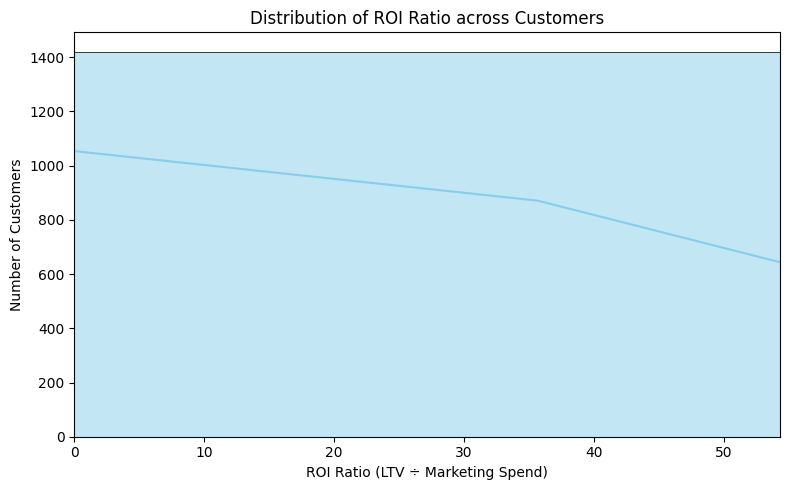

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

#ROI distribution histogram

plt.figure(figsize=(8, 5))
sns.histplot(customer_roi, x='roi_ratio', kde=True, color='skyblue')
plt.title('Distribution of ROI Ratio across Customers')
plt.xlabel('ROI Ratio (LTV ÷ Marketing Spend)')
plt.ylabel('Number of Customers')
plt.xlim(0, customer_roi['roi_ratio'].quantile(0.95))  # zoom into majority
plt.tight_layout()
plt.savefig('Distribution_of_ROI_by_Customers.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lukas\AppData\Local\Temp\ipykernel_8488\1434393707.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_location, x='location', y='roi_ratio', palette='Blues_d')


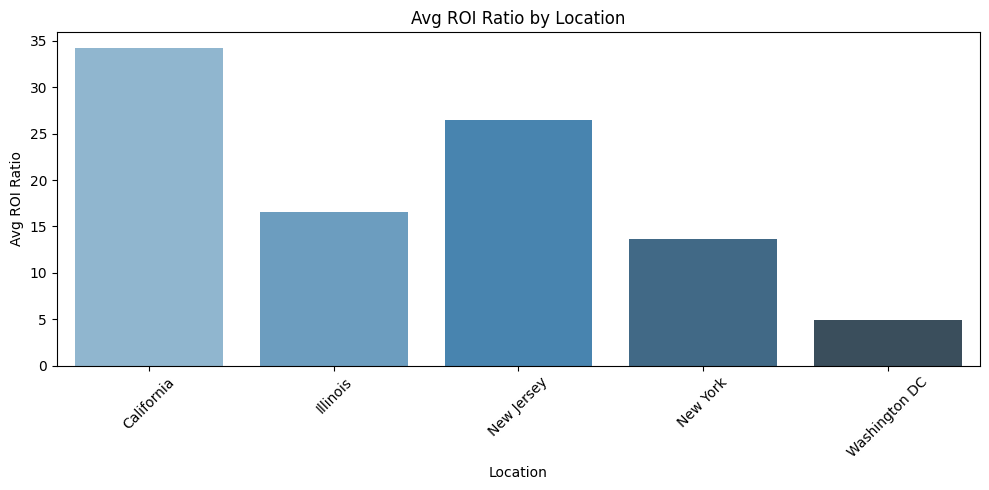

In [51]:
#Average ROI by Location

roi_by_location = customer_roi.groupby('location')['roi_ratio'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=roi_by_location, x='location', y='roi_ratio', palette='Blues_d')
plt.title('Avg ROI Ratio by Location')
plt.xlabel('Location')
plt.ylabel('Avg ROI Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_roi_by_location.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lukas\AppData\Local\Temp\ipykernel_8488\1817713844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_gender, x='gender', y='roi_ratio', palette='pastel')


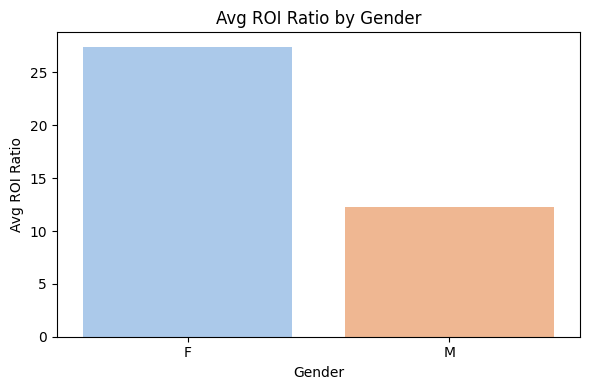

In [52]:
#Average ROI by Gender
roi_by_gender = customer_roi.groupby('gender')['roi_ratio'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=roi_by_gender, x='gender', y='roi_ratio', palette='pastel')
plt.title('Avg ROI Ratio by Gender')
plt.xlabel('Gender')
plt.ylabel('Avg ROI Ratio')
plt.tight_layout()
plt.savefig('avg_roi_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

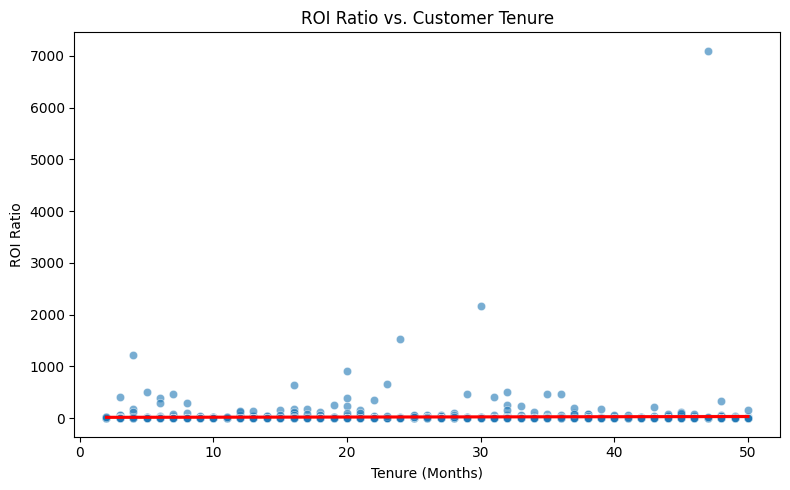

In [53]:
#Scatter Plot: ROI vs. Tenure Months
plt.figure(figsize=(8, 5))
sns.scatterplot(data=customer_roi, x='tenure_months', y='roi_ratio', alpha=0.6)
sns.regplot(data=customer_roi, x='tenure_months', y='roi_ratio', scatter=False, color='red')
plt.title('ROI Ratio vs. Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('ROI Ratio')
plt.tight_layout()
plt.savefig('roi_vs_tenure.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
SalesCoupon.head()

In [54]:
# Coupon Usage
# Calculation of the total number of coupons used by each customer
coupon_usage = SalesCoupon.groupby('customer_id')['coupon_code'].nunique().reset_index()
coupon_usage.columns = ['customer_id', 'coupon_count']

# Merging with the original customer_roi DataFrame
customer_roi = customer_roi.merge(coupon_usage, on='customer_id', how='left')

# Definition quartiles based on coupon usage
customer_roi['coupon_usage_quartile'] = pd.qcut(customer_roi['coupon_count'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

In [55]:
# ROI for each customer
customer_roi['roi_pct'] = customer_roi.apply(compute_roi, axis=1)
# Group by coupon usage quartile and calculate the average ROI
roi_by_coupon_quartile = customer_roi.groupby('coupon_usage_quartile')['roi_pct'].mean().reset_index()


C:\Users\Lukas\AppData\Local\Temp\ipykernel_8488\3047315053.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi_by_coupon_quartile = customer_roi.groupby('coupon_usage_quartile')['roi_pct'].mean().reset_index()


C:\Users\Lukas\AppData\Local\Temp\ipykernel_8488\1744823530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_coupon_quartile, x='coupon_usage_quartile', y='roi_pct', palette='viridis')


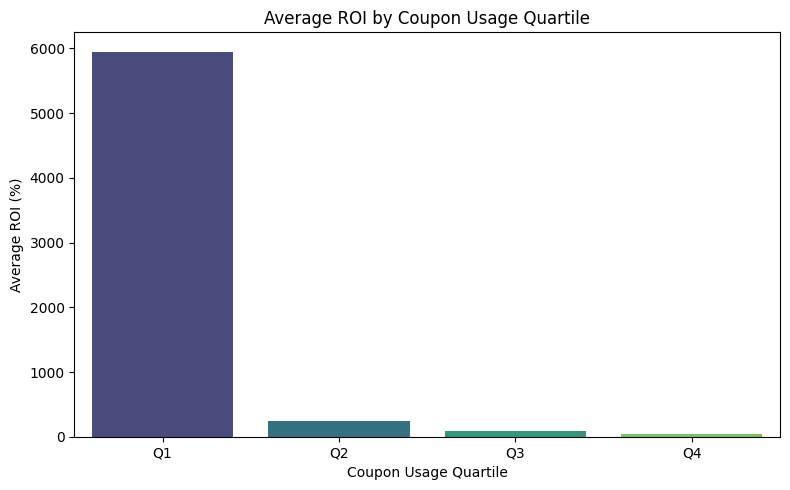

In [56]:
# Average ROI by Coupon Usage Quartile
plt.figure(figsize=(8, 5))

# Create a bar plot
sns.barplot(data=roi_by_coupon_quartile, x='coupon_usage_quartile', y='roi_pct', palette='viridis')

# Set the title and labels
plt.title('Average ROI by Coupon Usage Quartile')
plt.xlabel('Coupon Usage Quartile')
plt.ylabel('Average ROI (%)')

# Display the plot
plt.tight_layout()
plt.savefig('roi_by_coupon_quartile.png', dpi=300, bbox_inches='tight')
plt.show()



In [57]:
customer_roi.to_csv('customer_roi.csv', index=False)
roi_by_gender.to_csv('roi_by_gender.csv', index=False)
roi_by_location.to_csv('roi_by_location.csv', index=False)

